# Custom Linear Regression

In [1]:
from collections.abc import Callable
from pathlib import Path

import numpy as np
import pandas as pd
from utils import plot_cross_validation_performance

In [2]:
RANDOM_SEED = 42
TARGET_NAME = 'price'

In [3]:
df_train = pd.read_csv(Path('data') / '3 train_post_EDA.csv')
df_test = pd.read_csv(Path('data') / '3 test_post_EDA.csv')

display(df_train.head())
display(df_test.head())

,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


,area,bedrooms,bathrooms,price
0,0.164113,0.084228,-0.567518,15.562970
1,0.629346,0.084228,-0.567518,15.706965
2,-0.760589,-1.266538,-0.567518,15.135932
3,0.264192,0.084228,-0.567518,15.575091
4,0.872556,0.084228,1.514983,15.654948


**Standard linear regression** looks like this:
$$y = kx + b$$
**In more advanced quadratic forms** $y = kx^2+bx+c$ etc.

---

**In Data Science**, the more common convention is:
$$h(x) = w_0 + w_1x, \space where$$
- $w_1$ - trainable weight of a feature
- $w_0$ - trainable *bias*
- $x$ - an input feature

**In more complex forms in Data Science** (for $n$ trainable parameters):
$$h(x) = w_0 + \sum_{i=1}^n{w_ix_i}, \space where$$
- $n$ is the number of features
- $w_1, ... w_n$ - a vector of $n$ trainable weights
- $x_1, ... x_n$ - a matrix of input features
- $w_0$ - trainable *bias*

**In complex matrix form in Data Science** (for multidimensional spaces and computation efficiency):
$$h(x) = Xw, \space where$$
- $X$ - input features' matrix with an additional dummy features of $1$s in order to properly multiply the matrices
- $w$ - trainable weights vector

The matrix multiplication itself still preserves the sum of the products mechanism:

- $Xw = \begin{bmatrix} 1 & x_{1,1} & x_{1,2} & \dots & x_{1,n} \\ 1 & x_{2,1} & x_{2,2} & \dots & x_{2,n} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{m,1} & x_{m,2} & \dots & x_{m,n} \end{bmatrix} \begin{bmatrix} w_0 \\ w_1 \\ w_2 \\ \vdots \\ w_n \end{bmatrix} = \begin{bmatrix} (1 \cdot w_0) + (x_{1,1} \cdot w_1) + (x_{1,2} \cdot w_2) + \dots + (x_{1,n} \cdot w_n) \\ (1 \cdot w_0) + (x_{2,1} \cdot w_1) + (x_{2,2} \cdot w_2) + \dots + (x_{2,n} \cdot w_n) \\ \vdots \\ (1 \cdot w_0) + (x_{m,1} \cdot w_1) + (x_{m,2} \cdot w_2) + \dots + (x_{m,n} \cdot w_n) \end{bmatrix}=\begin{bmatrix} pred_0 \\ pred_1 \\ \dots \\ pred_m \end{bmatrix},\space where$ 
- $n$ is the number of features
- $m$ - number of samples. 
- One element $x_{mn}$ means "an $m$-th value of feature $n$.
- The col of $1$s added to properly multiply features because of the *bias* present

---

In [4]:
def add_np_ones_col(matrix: np.ndarray):
    np_ones = np.ones((matrix.shape[0], 1))
    return np.concatenate((np_ones, matrix), axis=1)

# напишіть функцію гіпотези лінійної регресії у векторному вигляді
def linear_forward_pass(features_matrix: np.ndarray, weights_col: np.ndarray):
    return features_matrix @ weights_col

# створіть функцію для обчислення функції втрат у векторному вигляді
def mse_loss(predictions: np.ndarray, ground_truth: np.ndarray):
    return (1/2) * np.sum((predictions - ground_truth)**2)/len(predictions)

def r2_score_custom(predictions: np.ndarray, ground_truth: np.ndarray):
    # 1. Total variation: how much the actual data spreads around its own mean
    var_mean = np.sum((ground_truth - np.mean(ground_truth)) ** 2)

    # 2. Residual variation: how much the actual data spreads around the regression line
    var_line = np.sum((ground_truth - predictions) ** 2)

    # if we only have 1 or less samples, R2 doesn't make sense
    if len(predictions) <= 1:
        return 0.0
    return 1 - (var_line / var_mean)

$$J(w) = \frac{1}{2n} * \sum_{i=1}^n{(\hat y_i-y_i)^2} \space (MSE), \space where$$
- $\frac{1}{2}$ is a coefficient to cancel out the future derivative's factor of 2. Given deep networks, by cancelling out $\frac{1}{2} \cdot \frac{2}{1}$, we eliminate billions of additional multiplications + omit dealing with numbers twice as huge, which helps the optimization problem of minimization. Without it, we would also have to cut our learning rate in half, and it would still be less efficient anyway.
- $n$: number of samples, $\frac{1}{n}$ makes it "error per point"
- $\hat y_i$: $i$-th prediction, **or in other words**: $\hat y_i = w_0 + \sum_{i=1}^n{w_i x_i}$ (forward pass)
- $y_i$: $i$-th ground truth

Now, in order to find the rate of change of our <u>loss</u> with respect to <u>weights</u> using chain rule, we need to find the partial derivative:

$$J(w) = \frac{\partial J(w)}{\partial w}=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{(\hat y_i-y_i)^2}]}{\partial w}$$

Substitute $\hat y_i$ for the forward pass where the variable $w$ is explicitly present in order to differentiate with respect to it:

$$\begin{gather}
J(w)=\frac{\partial [\frac{1}{2n}\sum_{i=1}^n{\left[(w_ix_i+w_0)-y_i\right]^2}]}{\partial w}=\frac{1}{2n}\sum_{i=1}^n{\underbrace{2(w_ix_i+w_0-y_i)}_{\text{outer derivative}} \cdot \underbrace{\frac{\partial(w_ix_i+w_0-y_i)}{\partial w_i}}_{\text{inner derivative (chain rule)}}}=
\\
=\frac{2}{2n}\sum_{i=1}^n{(w_ix_i+w_0-y_i)(x_i+0-0)}=\frac{1}{n}\sum_{i=1}^n{x_i(w_ix_i+w_0-y_i)}
\end{gather}$$

Substitute back:
$$\nabla J(w) = \frac{1}{n}\sum_{i=1}^n{x_i(\hat y_i-y_i)}$$

In order to vectorize it, we need to transpose to align the $i$-th error with the $i$-th feature across all samples (in order for the shapes to allow multiplication):
$$\nabla J(w) = \frac{1}{n}X^T(\hat y-y)$$

In [5]:
def mse_loss_der(features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    n = len(predictions)
    return (1/n) * features @ (predictions - ground_truth)

# реалізуйте один крок градієнтного спуску
def grad(lr: float, loss_der: Callable, features: np.ndarray, predictions: np.ndarray, ground_truth: np.ndarray):
    return lr * loss_der(features, predictions, ground_truth)

In [6]:
# n_fold determines the equal parts to split the dataset into
# 1 part will be used for validation and n_fold-1 parts for training
def cross_validation(n_folds: int, features: np.ndarray, target: np.ndarray):
    len_features = len(features)

    if len_features % n_folds != 0:
        err = f"Can't divide {len_features} by {n_folds} evenly. Please, change 'n_folds' or trim the data"
        raise ValueError(err)

    samples_per_fold = len_features // n_folds
    for i in range(n_folds):
        val_start_idx = i*samples_per_fold
        val_end_idx = i*samples_per_fold+samples_per_fold

        val_target = target[val_start_idx:val_end_idx]
        val_features = features[val_start_idx:val_end_idx]

        train_target = np.concatenate((target[:val_start_idx], target[val_end_idx:]), axis=0)
        train_features = np.concatenate((features[:val_start_idx], features[val_end_idx:]), axis=0)

        yield train_features, val_features, train_target, val_target

In [7]:
def train_and_validate_fold(lr: float, epochs: int, x_train: np.ndarray, y_train: np.ndarray, x_val: np.ndarray, y_val: np.ndarray, w_init: np.ndarray, verbose: bool = True):
    train_mses, train_r2s = [], []
    val_mses, val_r2s = [], []

    w = w_init.copy()

    for epoch in range(epochs):
        # 1. Forward pass & weight update on Train Data
        y_hat_train = linear_forward_pass(x_train, w)
        gradients = grad(lr, mse_loss_der, x_train.T, y_hat_train, y_train)
        w = w - gradients

        # 2. Record Train Metrics at this exact epoch step
        t_mse = mse_loss(y_hat_train, y_train)
        train_mses.append(t_mse)
        train_r2s.append(r2_score_custom(y_hat_train, y_train))

        # 3. Record Validation Metrics at this exact epoch step (using current w)
        y_hat_val = linear_forward_pass(x_val, w)
        v_mse = mse_loss(y_hat_val, y_val)
        val_mses.append(v_mse)
        val_r2s.append(r2_score_custom(y_hat_val, y_val))

    # 3. Print the final epoch's performance to see how the model finished
    if verbose:
        print(f"(train final epoch) MSE = {train_mses[-1]}")
        print(f"(train final epoch) RMSE = {np.sqrt(train_mses[-1])}")
        print(f"(train final epoch) R2 = {train_r2s[-1]}")
        print()
        print(f"(validation final epoch) MSE = {val_mses[-1]}")
        print(f"(validation final epoch) RMSE = {np.sqrt(val_mses[-1])}")
        print(f"(validation final epoch) R2 = {val_r2s[-1]}")
        print()

    return w, np.array(train_mses), np.array(train_r2s), np.array(val_mses), np.array(val_r2s)

In [8]:
INITIAL_WEIGHT_LOWER_BND = 1e-6
INITIAL_WEIGHT_UPPER_BND = 1e-5

X_train, y_train = df_train.drop(columns=[TARGET_NAME]), df_train[TARGET_NAME]
X_test, y_test = df_test.drop(columns=[TARGET_NAME]), df_test[TARGET_NAME]

rng = np.random.default_rng(seed=RANDOM_SEED)
#y_numpy = log_y.to_numpy().reshape(-1, 1)
w_init = rng.uniform(low=INITIAL_WEIGHT_LOWER_BND, high=INITIAL_WEIGHT_UPPER_BND, size=(X_train.shape[1]+1, 1))
X_train = add_np_ones_col(X_train)

In [9]:
X_train.shape

(433, 4)

In [10]:
# adjusting shape for cross-validation
X_train = X_train[:-1]
y_train = y_train[:-1]

In [11]:
LR = 1e-1
N_FOLDS = 24
EPOCHS = 1000

# Initialize structures to hold history profiles for each fold
fold_train_mses, fold_train_r2s = [], []
fold_val_mses, fold_val_r2s = [], []

# --- Cross-Validation Execution ---
for i, (train_features, val_features, train_target, val_target) in enumerate(cross_validation(n_folds=N_FOLDS, features=X_train, target=y_train.to_numpy().reshape(-1, 1))):
    print(f"Processing Fold {i+1}/{N_FOLDS}...")

    # do not update weights during cross-validation
    _, t_mse, t_r2, v_mse, v_r2 = train_and_validate_fold(LR, EPOCHS, train_features, train_target, val_features, val_target, w_init, verbose=True)

    fold_train_mses.append(t_mse)
    fold_train_r2s.append(t_r2)
    fold_val_mses.append(v_mse)
    fold_val_r2s.append(v_r2)

print("----- Cross-Validation Finished -----")

# --- Mathematical Matrix Averaging Across Folds ---
# Converts lists of 5 arrays into 2D matrices of shape (5, 1000), then takes mean along vertical axis
avg_train_loss = np.mean(np.array(fold_train_mses), axis=0)
avg_val_loss = np.mean(np.array(fold_val_mses), axis=0)
avg_train_r2 = np.mean(np.array(fold_train_r2s), axis=0)
avg_val_r2 = np.mean(np.array(fold_val_r2s), axis=0)

Processing Fold 1/24...
(train final epoch) MSE = 0.034284270117630015
(train final epoch) RMSE = 0.18516012021391112
(train final epoch) R2 = 0.49985439742322035

(validation final epoch) MSE = 0.024194194137112136
(validation final epoch) RMSE = 0.1555448299915884
(validation final epoch) R2 = 0.45323576226570583

Processing Fold 2/24...
(train final epoch) MSE = 0.033693265510994753
(train final epoch) RMSE = 0.18355725404078901
(train final epoch) R2 = 0.4920213677024651

(validation final epoch) MSE = 0.03794683504940322
(validation final epoch) RMSE = 0.19479947394539654
(validation final epoch) R2 = 0.5578331178226522

Processing Fold 3/24...
(train final epoch) MSE = 0.034354606182475385
(train final epoch) RMSE = 0.18534995598185447
(train final epoch) R2 = 0.5029516894606572

(validation final epoch) MSE = 0.022615201552397782
(validation final epoch) RMSE = 0.15038351489574175
(validation final epoch) R2 = 0.2970876484086099

Processing Fold 4/24...
(train final epoch) MSE =

In [12]:
best_v_mse = np.inf
best_option = {}

best_idx = np.argmin(avg_val_loss)
best_option = {
'lr': LR,
'n_folds': N_FOLDS,
'epoch': best_idx + 1,
'valid_MSE': f"{avg_val_loss[best_idx]:.4f}",
'valid_RMSE': f"{np.sqrt(avg_val_loss[best_idx]):.4f}",
'valid_R2': f"{avg_val_r2[best_idx]:.4f}",
'train_MSE': f"{avg_train_loss[best_idx]:.4f}",
'train_R2': f"{avg_train_r2[best_idx]:.4f}",
}

print("✅ Optimal Hyperparameter Target (Optimized on Averaged Validation Curve):")
print(f"  • lr:                 {LR}")
print(f"  • n_folds:            {N_FOLDS}")
print(f"  • Best Epoch:         {best_option['epoch']}")
print(f"  • Validation MSE:     {best_option['valid_MSE']}  (Train: {best_option['train_MSE']})")
print(f"  • Validation RMSE:    {best_option['valid_RMSE']}")
print(f"  • Validation R²:      {best_option['valid_R2']}  (Train: {best_option['train_R2']})")

✅ Optimal Hyperparameter Target (Optimized on Averaged Validation Curve):
  • lr:                 0.1
  • n_folds:            24
  • Best Epoch:         85
  • Validation MSE:     0.0346  (Train: 0.0338)
  • Validation RMSE:    0.1861
  • Validation R²:      0.4232  (Train: 0.4992)


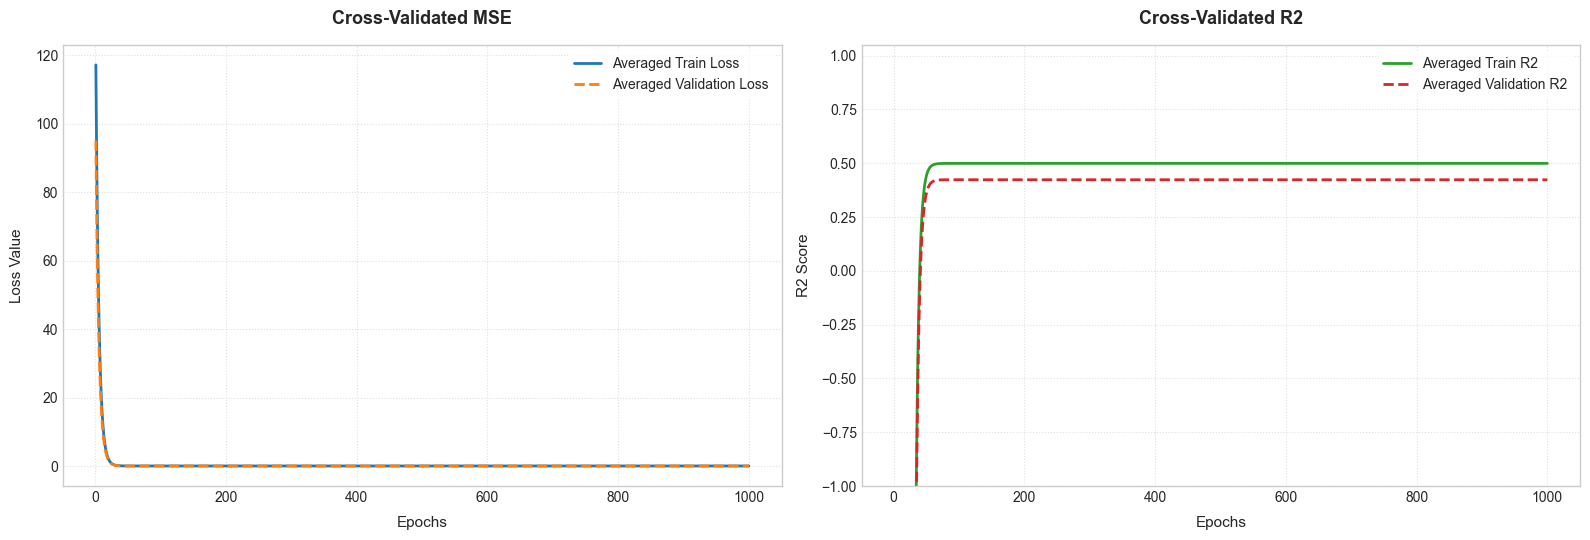

In [13]:
# Run the stylized output
plot_cross_validation_performance(avg_train_loss, avg_val_loss, avg_train_r2, avg_val_r2)

In [15]:
LR = 1e-1
EPOCHS = 85

# 2. Train the final model (passing complete training data to both slots)
w_final, _, _, _, _ = train_and_validate_fold(
    lr=LR,
    epochs=EPOCHS,
    x_train=X_train,
    y_train=y_train.to_numpy().reshape(-1, 1),
    x_val=X_train,
    y_val=y_train.to_numpy().reshape(-1, 1),
    w_init=w_init,
    verbose=True,
)

print("✅ Final weights vector optimized successfully.")
print(w_final)

(train final epoch) MSE = 0.03385535091388541
(train final epoch) RMSE = 0.1839982361705824
(train final epoch) R2 = 0.49902635413578444

(validation final epoch) MSE = 0.033854889199865366
(validation final epoch) RMSE = 0.18399698149661414
(validation final epoch) R2 = 0.4990331863365953

✅ Final weights vector optimized successfully.
[[15.30071595]
 [ 0.17779513]
 [ 0.06446597]
 [ 0.11841602]]


In [16]:
# 1. Prepare the test features by adding the column of ones
X_test_modified = add_np_ones_col(X_test)

# 2. Generate predictions (these will be in log-scale)
log_predictions = linear_forward_pass(X_test_modified, w_final)

# 3. Extract the actual log ground truth targets for comparison
log_ground_truth = y_test.to_numpy().reshape(-1, 1)

In [17]:
# Revert both predictions and ground truth back to raw currency values
final_predictions_usd = np.exp(log_predictions)
final_actual_prices_usd = np.exp(log_ground_truth)

# Let's inspect the first 5 entries side-by-side
for i in range(5):
    predicted = final_predictions_usd[i][0]
    actual = final_actual_prices_usd[i][0]
    error = predicted - actual
    print(f"House {i+1}: Predicted: ${predicted:,.2f} | Actual: ${actual:,.2f} | Deviation: ${error:,.2f}")

House 1: Predicted: $4,274,258.27 | Actual: $5,740,000.00 | Deviation: $-1,465,741.73
House 2: Predicted: $4,642,841.90 | Actual: $6,629,000.00 | Deviation: $-1,986,158.10
House 3: Predicted: $3,323,853.10 | Actual: $3,745,000.00 | Deviation: $-421,146.90
House 4: Predicted: $4,350,992.99 | Actual: $5,810,000.00 | Deviation: $-1,459,007.01
House 5: Predicted: $6,203,847.84 | Actual: $6,293,000.00 | Deviation: $-89,152.16


In [18]:
# Calculate real-world metrics
absolute_errors = np.abs(final_predictions_usd - final_actual_prices_usd)
mae_usd = np.mean(absolute_errors)
median_error_usd = np.median(absolute_errors)
test_r2 = r2_score_custom(final_predictions_usd, final_actual_prices_usd)

print("\n📊 FINAL HOLDOUT TEST SET PERFORMANCE:")
print(f"• Mean Absolute Error (MAE):     ${mae_usd:,.2f}")
print(f"• Median Absolute Error:         ${median_error_usd:,.2f}")
print(f"• Final Test R² Score:           {test_r2:.4f}")


📊 FINAL HOLDOUT TEST SET PERFORMANCE:
• Mean Absolute Error (MAE):     $1,002,871.90
• Median Absolute Error:         $751,392.86
• Final Test R² Score:           0.3852
